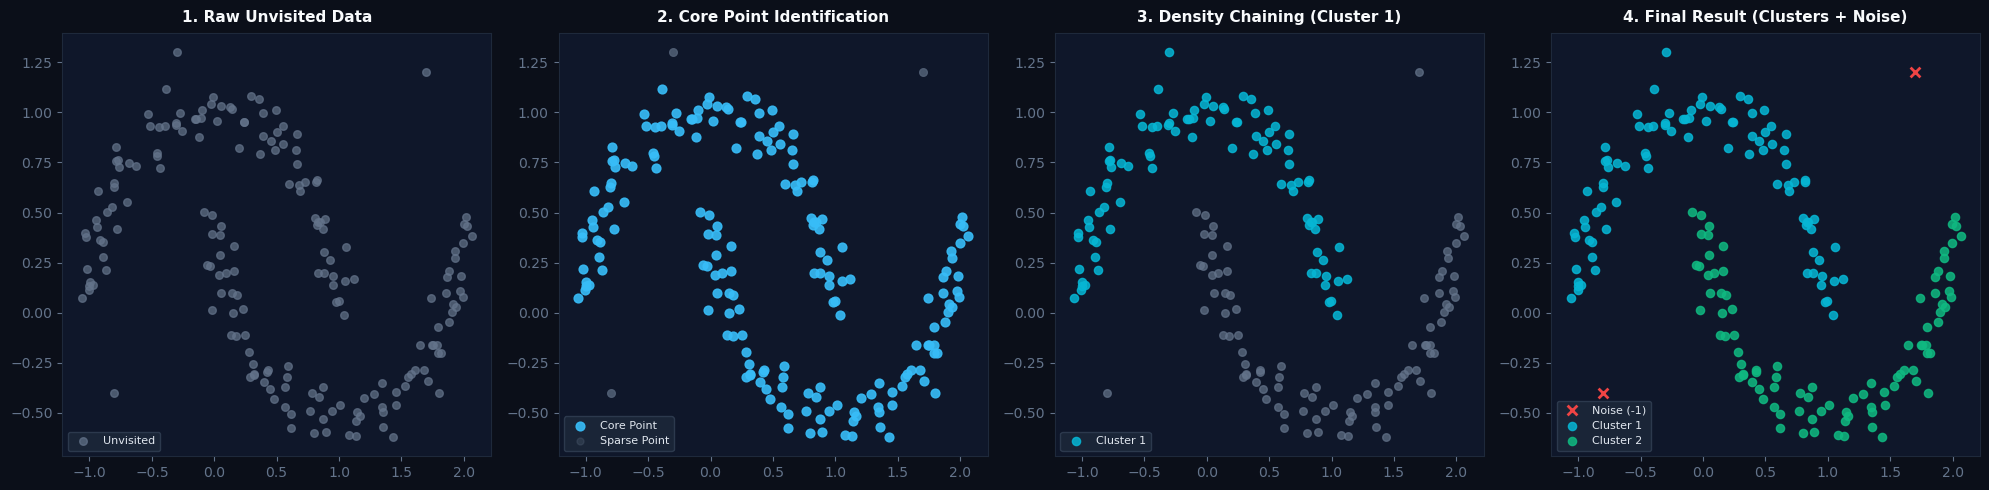

In [2]:
import matplotlib.pyplot as plt
import numpy as np


class VisualDBSCAN:
  """DBSCAN implementation with step-by-step cluster expansion snapshots."""

  def __init__(self, eps=0.25, min_samples=5):
    self.eps = eps
    self.min_samples = min_samples
    self.labels_ = None
    self.snapshots = []
    self.titles = []

  def _region_query(self, X, point_idx):
    distances = np.linalg.norm(X - X[point_idx], axis=1)
    return np.where(distances <= self.eps)[0]

  def fit(self, X):
    n_samples = X.shape[0]
    self.labels_ = np.zeros(n_samples, dtype=int)  # 0: Unvisited

    # 1. Snapshot: Initial Unvisited State
    self.snapshots.append(self.labels_.copy())
    self.titles.append("1. Raw Unvisited Data")

    # Precompute core points
    neighbors_list = [self._region_query(X, i) for i in range(n_samples)]
    core_mask = np.array([len(n) >= self.min_samples for n in neighbors_list])

    # 2. Snapshot: Density Identification (Core vs Non-Core)
    density_map = np.zeros(n_samples, dtype=int)
    density_map[core_mask] = 100  # Marker code for Core
    self.snapshots.append(density_map)
    self.titles.append("2. Core Point Identification")

    cluster_id = 0
    captured_first_expansion = False

    for idx in range(n_samples):
      if self.labels_[idx] != 0:
        continue

      if not core_mask[idx]:
        self.labels_[idx] = -1  # Noise
        continue

      cluster_id += 1
      self.labels_[idx] = cluster_id
      queue = list(neighbors_list[idx])

      # Breadth-first density traversal
      head = 0
      while head < len(queue):
        curr_neighbor = queue[head]
        head += 1

        if self.labels_[curr_neighbor] == -1:
          self.labels_[curr_neighbor] = cluster_id
        elif self.labels_[curr_neighbor] == 0:
          self.labels_[curr_neighbor] = cluster_id
          if core_mask[curr_neighbor]:
            queue.extend(neighbors_list[curr_neighbor])

      # 3. Snapshot: Save state after Cluster 1 completes
      if not captured_first_expansion and cluster_id == 1:
        self.snapshots.append(self.labels_.copy())
        self.titles.append("3. Density Chaining (Cluster 1)")
        captured_first_expansion = True

    # 4. Snapshot: Final Clustering Result
    self.snapshots.append(self.labels_.copy())
    self.titles.append("4. Final Result (Clusters + Noise)")
    return self

  def plot_steps(self, X):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), facecolor="#0b0f19")
    color_map = {
        -1: "#ef4444",  # Noise (Red)
        0: "#64748b",  # Unvisited (Slate Gray)
        1: "#06b6d4",  # Cluster 1 (Cyan)
        2: "#10b981",  # Cluster 2 (Emerald)
        100: "#38bdf8",  # Core Points (Sky Blue)
    }

    for i, ax in enumerate(axes):
      ax.set_facecolor("#0f172a")
      ax.set_title(
          self.titles[i], color="#f8fafc", fontsize=11, fontweight="bold", pad=8
      )
      snap = self.snapshots[i]

      for lbl in np.unique(snap):
        mask = snap == lbl
        if lbl == -1:
          ax.scatter(
              X[mask, 0],
              X[mask, 1],
              c=color_map[lbl],
              s=50,
              marker="x",
              linewidths=2,
              label="Noise (-1)",
          )
        elif lbl == 100:
          ax.scatter(
              X[mask, 0],
              X[mask, 1],
              c=color_map[lbl],
              s=40,
              label="Core Point",
              alpha=0.9,
          )
          ax.scatter(
              X[~mask, 0],
              X[~mask, 1],
              c="#475569",
              s=25,
              label="Sparse Point",
              alpha=0.4,
          )
        elif lbl == 0:
          ax.scatter(
              X[mask, 0],
              X[mask, 1],
              c=color_map[lbl],
              s=30,
              alpha=0.7,
              label="Unvisited" if i == 0 else None,
          )
        else:
          ax.scatter(
              X[mask, 0],
              X[mask, 1],
              c=color_map.get(lbl, "#a855f7"),
              s=35,
              alpha=0.85,
              label=f"Cluster {lbl}",
          )

      ax.tick_params(colors="#64748b")
      for spine in ax.spines.values():
        spine.set_color("#1e293b")
      ax.legend(
          loc="lower left",
          fontsize=8,
          facecolor="#1e293b",
          edgecolor="#334155",
          labelcolor="#e2e8f0",
      )

    plt.tight_layout()
    plt.show()


# =========================================================================
# RUN DEMO
# =========================================================================
if __name__ == "__main__":
  np.random.seed(42)

  # 1. Non-convex synthetic double crescent moons
  n_pts = 90
  theta1 = np.linspace(0, np.pi, n_pts)
  moon1 = np.column_stack([np.cos(theta1), np.sin(theta1)]) + np.random.normal(
      0, 0.08, (n_pts, 2)
  )

  theta2 = np.linspace(0, np.pi, n_pts)
  moon2 = np.column_stack(
      [1.0 - np.cos(theta2), 0.5 - np.sin(theta2)]
  ) + np.random.normal(0, 0.08, (n_pts, 2))

  # 2. Add random background outliers
  noise = np.array([
      [-0.8, -0.4],
      [1.7, 1.2],
      [0.5, 0.9],
      [-0.3, 1.3],
      [1.8, -0.4],
      [0.8, -0.6],
  ])
  X = np.vstack([moon1, moon2, noise])

  # 3. Fit and generate visual progression
  dbscan_viz = VisualDBSCAN(eps=0.25, min_samples=5)
  dbscan_viz.fit(X)
  dbscan_viz.plot_steps(X)

In [3]:
import numpy as np


class DBSCANScratch:
  """Density-Based Spatial Clustering of Applications with Noise (DBSCAN)."""

  def __init__(self, eps=0.5, min_samples=5):
    self.eps = eps
    self.min_samples = min_samples
    self.labels_ = None

  def _region_query(self, X, point_idx):
    """Find all point indices within eps radius of X[point_idx]."""
    # Euclidean distance computation across all points
    dists = np.linalg.norm(X - X[point_idx], axis=1)
    return np.where(dists <= self.eps)[0]

  def _expand_cluster(self, X, labels, point_idx, neighbors, cluster_id):
    """Expand cluster using breadth-first density reachable search."""
    labels[point_idx] = cluster_id
    queue = list(neighbors)

    i = 0
    while i < len(queue):
      neighbor_idx = queue[i]
      i += 1

      # If previously marked as noise, claim it as a border point
      if labels[neighbor_idx] == -1:
        labels[neighbor_idx] = cluster_id

      # If not visited yet
      elif labels[neighbor_idx] == 0:
        labels[neighbor_idx] = cluster_id
        point_neighbors = self._region_query(X, neighbor_idx)

        # If it's a Core point, expand search space
        if len(point_neighbors) >= self.min_samples:
          queue.extend(point_neighbors)

  def fit(self, X):
    n_samples = X.shape[0]
    # 0 = unvisited, -1 = noise, >= 1 = cluster ID
    labels = np.zeros(n_samples, dtype=int)
    cluster_id = 0

    for point_idx in range(n_samples):
      # Skip already visited points
      if labels[point_idx] != 0:
        continue

      neighbors = self._region_query(X, point_idx)

      # Check Core point condition
      if len(neighbors) < self.min_samples:
        labels[point_idx] = -1  # Mark temporarily as noise
      else:
        cluster_id += 1
        self._expand_cluster(X, labels, point_idx, neighbors, cluster_id)

    self.labels_ = labels
    return self

  def fit_predict(self, X):
    self.fit(X)
    return self.labels_


# =========================================================================
# DEMO EXECUTION
# =========================================================================
if __name__ == "__main__":
  np.random.seed(42)

  # 1. Generate non-convex concentric crescent moons
  n_pts = 80
  theta1 = np.linspace(0, np.pi, n_pts)
  moon1 = np.column_stack(
      [np.cos(theta1), np.sin(theta1)]
  ) + np.random.normal(0, 0.08, (n_pts, 2))

  theta2 = np.linspace(0, np.pi, n_pts)
  moon2 = (
      np.column_stack([1.0 - np.cos(theta2), 0.5 - np.sin(theta2)])
      + np.random.normal(0, 0.08, (n_pts, 2))
  )

  # 2. Add isolated noise outliers
  noise = np.array([[-0.8, -0.5], [1.8, 1.2], [0.5, 0.8], [-0.2, 1.4]])

  X = np.vstack([moon1, moon2, noise])

  # 3. Train DBSCAN from scratch
  dbscan = DBSCANScratch(eps=0.25, min_samples=5)
  labels = dbscan.fit_predict(X)

  unique_clusters = set(labels) - {-1}
  n_noise = np.sum(labels == -1)

  print("=" * 65)
  print("  DBSCAN CLUSTERING FROM SCRATCH (PURE NUMPY)")
  print("=" * 65)
  print(f"Total Points Processed        : {X.shape[0]}")
  print(f"Epsilon Neighborhood Radius   : {dbscan.eps}")
  print(f"MinPts Density Threshold      : {dbscan.min_samples}")
  print(f"Estimated Clusters Discovered : {len(unique_clusters)}")
  print(f"Estimated Noise Points (-1)   : {n_noise}")
  print("=" * 65)

  DBSCAN CLUSTERING FROM SCRATCH (PURE NUMPY)
Total Points Processed        : 164
Epsilon Neighborhood Radius   : 0.25
MinPts Density Threshold      : 5
Estimated Clusters Discovered : 2
Estimated Noise Points (-1)   : 3
